### **Exercícios de Regressão – Linear, Múltipla e Polinomial**


### 1. Regressão Linear Simples – Exercícios

**Exercício 1:**

Neste exercício, vamos gerar dados seguindo o modelo:

$$y = 3x + 2 + w,$$


onde:

- $x$ é um vetor coluna com $N = 1000$ amostras geradas de uma distribuição uniforme no intervalo $[-1, 1]$;
- $w$ é um vetor coluna com $N$ amostras extraídas de uma distribuição normal Gaussiana com média zero e variância unitária.

O objetivo é ajustar um modelo de regressão linear e comparar os coeficientes reais com os estimados. Plote a função original, os dados ruidosos e a reta estimada.


Coeficiente estimado (â): 2.921
Intercepto estimado (b̂): 2.013


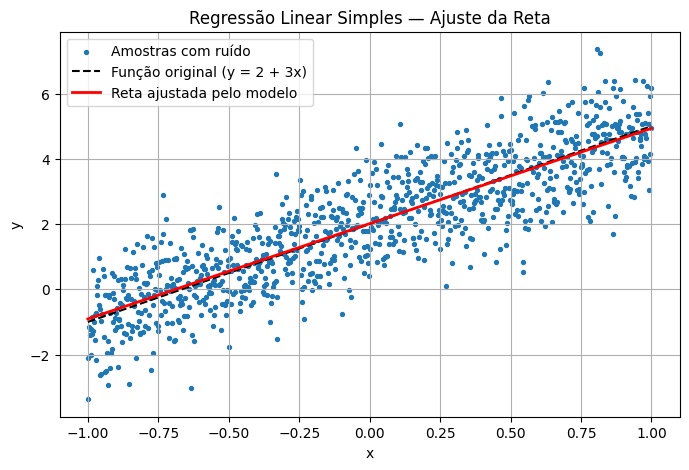

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Gerando os dados
N = 1000
x = np.linspace(-1, 1, N).reshape(N, 1)
w = np.random.randn(N, 1)
y = 2 + 3 * x
y_noisy = y + w

# 2. Criando o modelo de Regressão Linear
model = LinearRegression()

# 3. Treinando o modelo com os dados ruidosos
model.fit(x, y_noisy)

# 4. Obtendo parâmetros estimados
a_hat = model.coef_[0][0]
b_hat = model.intercept_[0]

print(f"Coeficiente estimado (â): {a_hat:.3f}")
print(f"Intercepto estimado (b̂): {b_hat:.3f}")

# 5. Predição nos mesmos pontos
y_pred = model.predict(x)

# 6. Visualização do resultado
plt.figure(figsize=(8,5))
plt.scatter(x, y_noisy, s=8, label="Amostras com ruído")
plt.plot(x, y, 'k--', label="Função original (y = 2 + 3x)")
plt.plot(x, y_pred, 'r', linewidth=2, label="Reta ajustada pelo modelo")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Regressão Linear Simples — Ajuste da Reta")
plt.legend()
plt.grid(True)
plt.show()



**Exercício 2:**

Crie um conjunto de dados com $N = 100$ amostras seguindo o modelo:

$$y = \beta_0 + \beta_1 x + w,$$


onde:

- $x$ é um vetor coluna com $N$ elementos gerados a partir de uma distribuição **uniforme** no intervalo $[0, 10]$, representando os **anos de uso**;
- $\beta_0 = 50\,000$ é o preço inicial sem uso;
- $\beta_1 = -3\,000$ é a taxa de desvalorização por ano (relação linear decrescente);
- $w$ é um vetor coluna com $N$ elementos amostrados de uma **distribuição normal Gaussiana** com média zero e desvio padrão $\sigma = 2000$, representando ruído no preço.

Treine um modelo de regressão linear para estimar $\beta_0$ e $\beta_1$ e compare esses valores com os coeficientes reais. Plote a função original, os dados ruidosos e a reta estimada.

-----------------------------------------------------------

Parâmetros Reais: β0 = 50000, β1 = -3000
Parâmetros Estimados: β̂0 = 50715.81, β̂1 = -3097.04


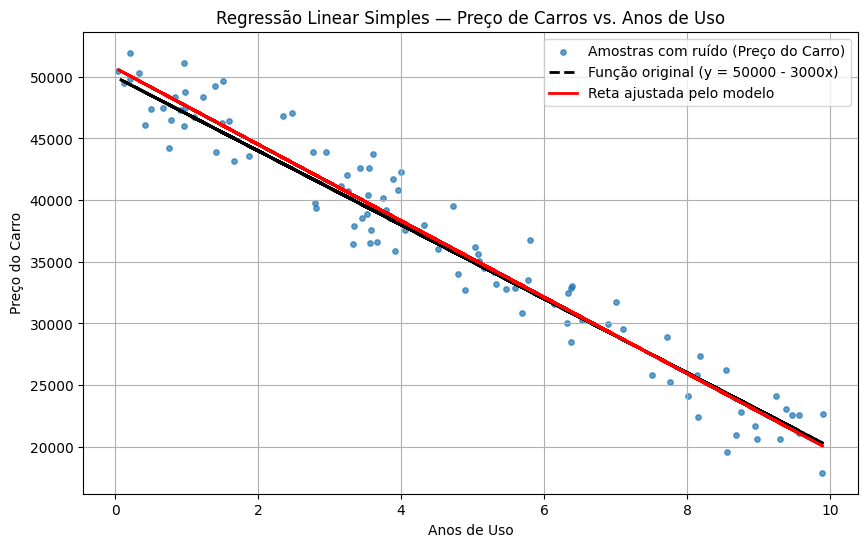

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

N = 100
x = np.random.uniform(0, 10, N).reshape(N, 1)
beta_0 = 50000
beta_1 = -3000
sigma = 2000

w = np.random.normal(0, sigma, N).reshape(N, 1)

y = beta_0 + beta_1 * x
y_noisy = y + w

# 2. Criando o modelo de Regressão Linear
model = LinearRegression()

# 3. Treinando o modelo com os dados ruidosos
model.fit(x, y_noisy)

# 4. Obtendo parâmetros estimados
beta_0_hat = model.intercept_[0]
beta_1_hat = model.coef_[0][0]

print(f"Parâmetros Reais: β0 = {beta_0}, β1 = {beta_1}")
print(f"Parâmetros Estimados: β̂0 = {beta_0_hat:.2f}, β̂1 = {beta_1_hat:.2f}")

# 5. Predição nos mesmos pontos
y_pred = model.predict(x)

# 6. Visualização do resultado
plt.figure(figsize=(10, 6))
plt.scatter(x, y_noisy, s=15, label="Amostras com ruído (Preço do Carro)", alpha=0.7)
plt.plot(x, y, 'k--', label="Função original (y = 50000 - 3000x)", linewidth=2)
plt.plot(x, y_pred, 'r-', label="Reta ajustada pelo modelo", linewidth=2)

plt.xlabel("Anos de Uso")
plt.ylabel("Preço do Carro")
plt.title("Regressão Linear Simples — Preço de Carros vs. Anos de Uso")
plt.legend()
plt.grid(True)
plt.show()

### 2. Regressão Linear Múltipla – Exercícios

**Exercício 3:**

Considere o modelo linear:

$$y = 5 + 3x_1 - 2x_2 + w,$$

onde:

- $x_1$ e $x_2$ são vetores coluna com $N = 1000$ amostras geradas de forma independente a partir de uma distribuição uniforme no intervalo $[-1, 1]$;
- $w$ é um vetor coluna com $N$ amostras extraídas de uma distribuição normal Gaussiana com média zero e desvio padrão $\sigma = 0.5$.

O objetivo é ajustar um modelo de regressão linear múltipla e comparar os coeficientes reais com os estimados. Plote a função original, os dados ruidosos e a reta estimada.


Intercepto estimado (b̂): 4.998360409734566
Coeficientes estimados (â): [ 3.02529646 -2.00424603]


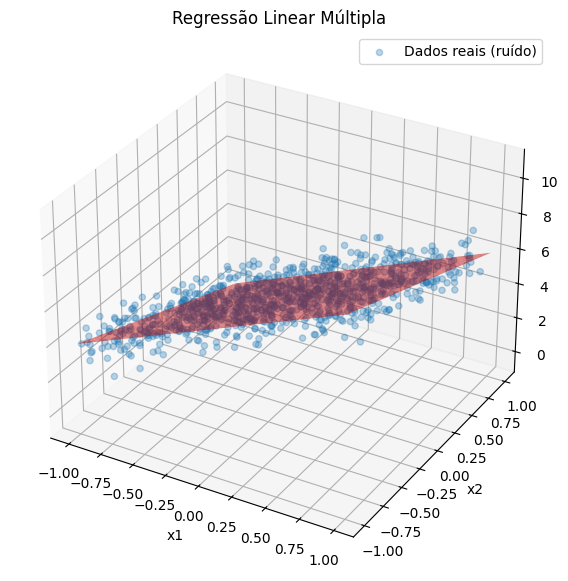

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Gerando os dados
N = 1000

# Duas variáveis de entrada
x1 = np.random.uniform(-1, 1, N)
x2 = np.random.uniform(-1, 1, N)

# Junta em uma matriz (N x 2)
X = np.column_stack((x1, x2))

# Função original
y = 5 + 3*x1 - 2*x2

# Ruído
w = np.sqrt(0.5) * np.random.randn(N) # Aqui !! o sigma significa np.sqrt(0.5)
y_noisy = y + w

# 2. Modelo
model = LinearRegression()

# 3. Treinamento
model.fit(X, y_noisy)

# 4. Parâmetros estimados
b_hat = model.intercept_
a_hat = model.coef_

print("Intercepto estimado (b̂):", b_hat)
print("Coeficientes estimados (â):", a_hat)

# 5. Predição
y_pred = model.predict(X)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1, x2, y_noisy, alpha=0.3, label="Dados reais (ruído)")

# Criando um grid para o plano
x1_grid, x2_grid = np.meshgrid(
    np.linspace(min(x1), max(x1), 40),
    np.linspace(min(x2), max(x2), 40))

# Plano previsto
y_grid = (b_hat
    + a_hat[0] * x1_grid
    + a_hat[1] * x2_grid)

# Superfície do plano
ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.5, color='red')
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")
ax.set_title("Regressão Linear Múltipla")
plt.legend()
plt.show()

**Exercício 4:**

Neste exercício, vamos investigar o impacto da normalização quando trabalhamos com variáveis que possuem **escalas muito diferentes**.

Considere:

- $x_1$: variável na escala de **0 a 10**.  
- $x_2$: variável na escala de **0 a 10.000**.

O modelo real utilizado para gerar os dados será:

$$y = 4x_1 + 0.002x_2 + w,$$

onde o ruído $w$ segue uma distribuição normal Gaussiana com média zero e desvio padrão $\sigma = 5$.

O objetivo é:

1. Treinar um **modelo sem normalização**.  
2. Treinar um **modelo com normalização via StandardScaler**.  
3. Comparar coeficientes e plotar a função original, os dados ruidosos e a reta estimada.  
4. Explicar por que a normalização impacta os coeficientes.

Modelo sem Normalização
Intercepto real (β0): 0
Coeficientes reais (β1, β2): [4.0, 0.002]
Intercepto estimado (b̂) (SEM normalização): -0.1239
Coeficientes estimados (â) (SEM normalização): [4.0876, 0.0019]


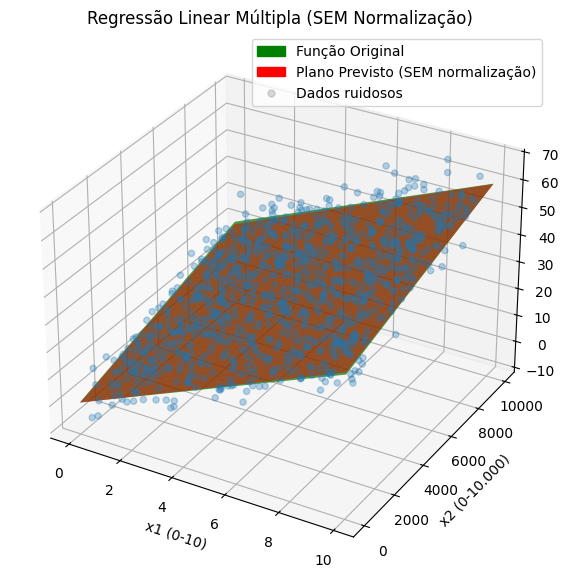

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 1. Gerando os dados
N = 1000

# Duas variáveis de entrada com escalas diferentes
x1 = np.random.uniform(0, 10, N)
x2 = np.random.uniform(0, 10000, N)

# Junta em uma matriz (N x 2)
X = np.column_stack((x1, x2))

sigma = 5
y_true = 4 * x1 + 0.002 * x2
w = sigma * np.random.randn(N)
y_noisy = y_true + w

print("Modelo sem Normalização")
model_unscaled = LinearRegression(fit_intercept=True)

# 3. Treinamento
model_unscaled.fit(X, y_noisy)

# 4. Parâmetros estimados
b_hat_unscaled = model_unscaled.intercept_
a_hat_unscaled = model_unscaled.coef_

print(f"Intercepto real (β0): {0}")
print(f"Coeficientes reais (β1, β2): [4.0, 0.002]")
print(f"Intercepto estimado (b̂) (SEM normalização): {b_hat_unscaled:.4f}")
print(f"Coeficientes estimados (â) (SEM normalização): [{a_hat_unscaled[0]:.4f}, {a_hat_unscaled[1]:.4f}]")

# 5. Predição
y_pred_unscaled = model_unscaled.predict(X)

# 6. Visualização do resultado sem normalização
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1, x2, y_noisy, alpha=0.3, label="Dados ruidosos")

x1_grid, x2_grid = np.meshgrid(
    np.linspace(x1.min(), x1.max(), 40),
    np.linspace(x2.min(), x2.max(), 40))

y_original_grid = 4 * x1_grid + 0.002 * x2_grid
ax.plot_surface(x1_grid, x2_grid, y_original_grid, alpha=0.7, color='green', label='Função Original', rstride=100, cstride=100)

y_pred_grid_unscaled = (b_hat_unscaled
    + a_hat_unscaled[0] * x1_grid
    + a_hat_unscaled[1] * x2_grid)
ax.plot_surface(x1_grid, x2_grid, y_pred_grid_unscaled, alpha=0.5, color='red', label='Plano Previsto (SEM normalização)')

ax.set_xlabel("x1 (0-10)")
ax.set_ylabel("x2 (0-10.000)")
ax.set_zlabel("y")
ax.set_title("Regressão Linear Múltipla (SEM Normalização)")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', edgecolor='green', label='Função Original'),
                   Patch(facecolor='red', edgecolor='red', label='Plano Previsto (SEM normalização)'),
                   plt.Line2D([0], [0], marker='o', color='gray', label='Dados ruidosos', markersize=5, linestyle='None', alpha=0.3)]
ax.legend(handles=legend_elements)

plt.show()

Modelo COM Normalização (via StandardScaler)
Intercepto estimado (b̂) (com normalização): 29.8591
Coeficientes estimados (â) (com normalização): [12.0283, 5.5969]

Coeficientes estimados (â) (com normalização): [4.0876, 0.0019]
Intercepto estimado (b̂) (com normalização): -0.1239


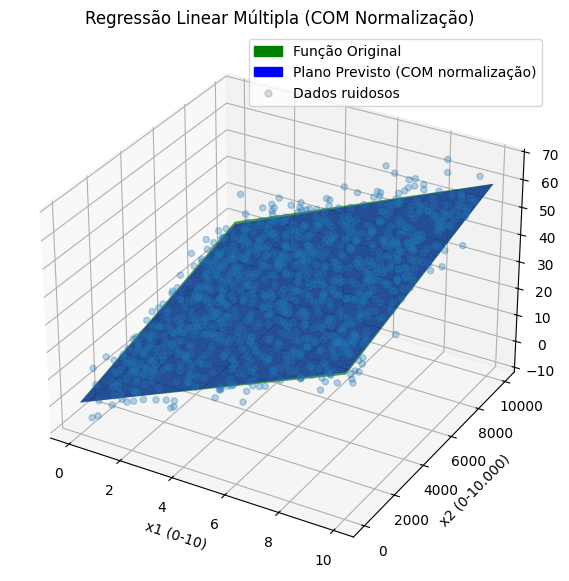

In [13]:
print("Modelo com Normalização (via StandardScaler)")

# 2. Normalização dos dados de entrada X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Treinar um modelo COM Normalização
model_scaled = LinearRegression(fit_intercept=True)

# 3. Treinamento com dados normalizados
model_scaled.fit(X_scaled, y_noisy)

# 4. Parâmetros estimados COM normalização
b_hat_scaled = model_scaled.intercept_
a_hat_scaled = model_scaled.coef_

print(f"Intercepto estimado (b̂) (com normalização): {b_hat_scaled:.4f}")
print(f"Coeficientes estimados (â) (com normalização): [{a_hat_scaled[0]:.4f}, {a_hat_scaled[1]:.4f}]")


# Parâmetros de escala e média do StandardScaler
mean_x = scaler.mean_
std_x = scaler.scale_

a_hat_scaled_denormalized = a_hat_scaled / std_x
b_hat_scaled_denormalized = b_hat_scaled - np.sum(a_hat_scaled * mean_x / std_x)

print(f"\nCoeficientes estimados (â) (com normalização): [{a_hat_scaled_denormalized[0]:.4f}, {a_hat_scaled_denormalized[1]:.4f}]")
print(f"Intercepto estimado (b̂) (com normalização): {b_hat_scaled_denormalized:.4f}")


# 5. Predição com normalização
y_pred_scaled = model_scaled.predict(X_scaled)

# 6. Visualização do resultado com normalização
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1, x2, y_noisy, alpha=0.3, label="Dados ruidosos")

x1_grid_scaled = (x1_grid - mean_x[0]) / std_x[0]
x2_grid_scaled = (x2_grid - mean_x[1]) / std_x[1]

y_pred_grid_scaled = (b_hat_scaled
    + a_hat_scaled[0] * x1_grid_scaled
    + a_hat_scaled[1] * x2_grid_scaled)

ax.plot_surface(x1_grid, x2_grid, y_pred_grid_scaled, alpha=0.5, color='blue', label='Plano Previsto (COM normalização)')

ax.plot_surface(x1_grid, x2_grid, y_original_grid, alpha=0.7, color='green', label='Função Original', rstride=100, cstride=100)

ax.set_xlabel("x1 (0-10)")
ax.set_ylabel("x2 (0-10.000)")
ax.set_zlabel("y")
ax.set_title("Regressão Linear Múltipla (COM Normalização)")

from matplotlib.patches import Patch
legend_elements_scaled = [Patch(facecolor='green', edgecolor='green', label='Função Original'),
                          Patch(facecolor='blue', edgecolor='blue', label='Plano Previsto (COM normalização)'),
                          plt.Line2D([0], [0], marker='o', color='gray', label='Dados ruidosos', markersize=5, linestyle='None', alpha=0.3)]
ax.legend(handles=legend_elements_scaled)

plt.show()

Comparação de Coeficientes e Explicação

In [14]:
print("Atenção: Os valores reais são Intercepto=0, Coeficientes=[4.0, 0.002]")

print("Resultados")
print(f"Modelo sem Normalização (Intercepto, Coefs): [{b_hat_unscaled:.4f}, {a_hat_unscaled[0]:.4f}, {a_hat_unscaled[1]:.4f}]")
print(f"Modelo com Normalização (Intercepto, Coefs desnormalizados): [{b_hat_scaled_denormalized:.4f}, {a_hat_scaled_denormalized[0]:.4f}, {a_hat_scaled_denormalized[1]:.4f}]")

print("\nResumo da Explicação")
print("A Regressão Linear funciona bem com ou sem normalização; os resultados finais são iguais")
print("A normalização (ajustar a escala dos dados) é como colocar todos na mesma régua")
print("Ela é útil para: aprender mais rápido, garantir que todas as variáveis sejam tratadas igualmente em modelos complexos e ajudar a entender a importância relativa de cada fator.")

Atenção: Os valores reais são Intercepto=0, Coeficientes=[4.0, 0.002]
Resultados
Modelo SEM Normalização (Intercepto, Coefs): [-0.1239, 4.0876, 0.0019]
Modelo COM Normalização (Intercepto, Coefs desnormalizados): [-0.1239, 4.0876, 0.0019]

Resumo da Explicação
A Regressão Linear funciona bem com ou sem normalização; os resultados finais são iguais
A normalização (ajustar a escala dos dados) é como colocar todos na mesma régua
Ela é útil para: aprender mais rápido, garantir que todas as variáveis sejam tratadas igualmente em modelos complexos e ajudar a entender a importância relativa de cada fator.


### 3. Regressão Polinomial – Exercícios

**Exercício 5:**
Considere o seguinte modelo gerador de dados:

$$
y = 2x^2 - x + 1 + w,
$$

onde:

- $x$ é um vetor coluna com $N = 1000$ amostras geradas de forma independente a partir de uma distribuição uniforme no intervalo $[-1, 1]$;
- $w$ é um vetor coluna com $N$ amostras extraídas de uma distribuição normal Gaussiana com média zero e desvio padrão $\sigma = 0.5$.

O objetivo é analisar o comportamento da regressão polinomial ao tentar aproximar um modelo não linear verdadeiro utilizando diferentes graus de complexidade.
Treine modelos de regressão polinomial considerando as seguintes hipóteses:

- Grau 1 (modelo linear):

$$
y \approx \beta_0 + \beta_1 x
$$

- Grau 2 (modelo correto em relação ao processo gerador):

$$
y \approx \beta_0 + \beta_1 x + \beta_2 x^2
$$

- Grau 3 (modelo superparametrizado):

$$
y \approx \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3
$$

**Objetivo:**

Comparar o desempenho dos três modelos em termos de:

- capacidade de aproximação da função verdadeira;
- plotar a função original, os dados ruidosos e a reta estimada.
- impacto da complexidade do modelo (underfitting vs. overfitting);
- influência do termo de ruído $w$ na estimativa dos coeficientes.

### Coeficientes e MSE para cada grau de Polinômio ###
Grau 1: Coeficientes Estimados = ['1.6763', '0.0000', '-1.0223'], MSE = 0.357215
Grau 2: Coeficientes Estimados = ['1.0174', '0.0000', '-1.0223', '1.9728'], MSE = 0.000301
Grau 3: Coeficientes Estimados = ['1.0174', '0.0000', '-1.0376', '1.9728', '0.0254'], MSE = 0.000316


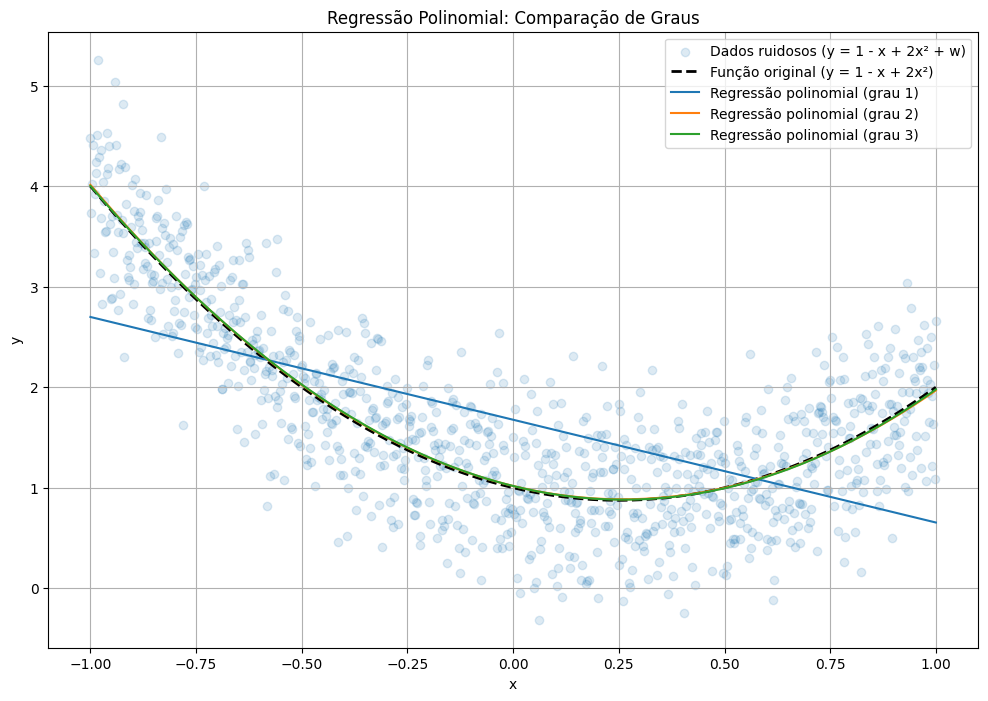

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# 1. Dados
N = 1000
x = np.linspace(-1, 1, N).reshape(-1, 1)

sigma_w = 0.5
w = sigma_w * np.random.randn(N, 1)

y_true = 1 - x + 2 * (x**2)

# Dados com ruído
y_noisy = y_true + w


degrees = [1, 2, 3]
models = {}
y_preds = {}
coefficients = {}

plt.figure(figsize=(12, 8))
plt.scatter(x, y_noisy, alpha=0.15, label="Dados ruidosos (y = 1 - x + 2x² + w)")
plt.plot(x, y_true, 'k--', label="Função original (y = 1 - x + 2x²)", linewidth=2)

print("Coeficientes e MSE para cada grau de Polinômio")
for degree in degrees:
    # 2. Transformação polinomial
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    X_poly = poly.fit_transform(x)

    # 3. Treinamento
    model = LinearRegression()
    model.fit(X_poly, y_noisy)
    models[degree] = model

    # 4. Predição
    y_pred = model.predict(X_poly)
    y_preds[degree] = y_pred
    coeffs = [model.intercept_[0]] + list(model.coef_.flatten())
    coefficients[degree] = coeffs

    mse = mean_squared_error(y_true, y_pred)
    print(f"Grau {degree}: Coeficientes Estimados = {['{:.4f}'.format(c) for c in coeffs]}, MSE = {mse:.6f}")


    plt.plot(x, y_pred, label=f"Regressão polinomial (grau {degree})", linewidth=1.5)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Regressão Polinomial: Comparação de Graus")
plt.legend()
plt.grid(True)
plt.show()